# Topology Repair Demo — Part A（toy）

用最小手工資料，示範路網「拓撲修復」為什麼需要、怎麼運作。

**問題**：OSM 以 Way 儲存道路，一條 Way 是一整段 LineString，交叉點常落在某條路的**中間座標**而非端點。
若只用端點建圖，交叉的兩條路不共享節點 → 圖斷裂。

**關鍵心智模型**：graph 的連通看的是「有沒有共用**節點**」，不是「幾何上有沒有碰到」。
同一個座標 `(5,0)`，對某條路是端點（會變節點）、對另一條路只是中間點（不會變節點）→ 沒有共用節點 → 不連通。

對應 `ARCHITECTURE.md §3.1`。L1 toy，不依賴 backend/data。

In [1]:
# 可攜策略：圖內文字一律用英文（跨機器 / GitHub render 不缺字），中文解說寫在 Markdown cell。
# 字型設定改成「本機有 CJK 才套用」的優雅版——沒有也不報錯，日後想在圖內加中文才用得到。
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _f in ("Noto Sans CJK TC", "PingFang TC", "Microsoft JhengHei"):
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f]
        break
plt.rcParams["axes.unicode_minus"] = False

# notebook 用後端 venv 的 kernel 跑；import 真實 pipeline 的 1m 座標捨入 helper
from app.services.graph_builder import _round_coord
import networkx as nx
from collections import defaultdict
from shapely.geometry import LineString

# road A 東西向：(5,0) 是它的『中間點』；road B 南北向：(5,0) 是它的『端點』
roads = {
    "A": LineString([(0, 0), (5, 0), (10, 0)]),
    "B": LineString([(5, 0), (5, 8)]),
}
roads

{'A': <LINESTRING (0 0, 5 0, 10 0)>, 'B': <LINESTRING (5 0, 5 8)>}

## 共用的繪圖 helper：依「連通分量」著色 + 畫出 graph 節點

修復前後**幾何完全一樣**，差別只在**拓撲**（節點/邊/連通分量）。
所以純畫線看不出差別 —— 要畫的是拓撲本身：

- **道路線**依所屬連通分量上色（不同色 = 不同的「獨立路網」）
- **graph 節點**畫成圓點；degree ≥ 3 的路口節點放大 + 黑框強調

In [2]:
COMP_COLORS = plt.cm.Set1.colors  # 一組對比色，index = 連通分量編號

def draw_graph_2d(G, roads, title, ax):
    comps = list(nx.connected_components(G))
    node_comp = {n: i for i, comp in enumerate(comps) for n in comp}

    # 1) 畫真實道路幾何，依所屬連通分量上色
    for name, line in roads.items():
        xs, ys = line.xy
        n0 = _round_coord(*line.coords[0])
        ci = node_comp.get(n0, 0)
        ax.plot(xs, ys, color=COMP_COLORS[ci], lw=3, zorder=1, alpha=0.8)
        mid = line.interpolate(0.5, normalized=True)
        ax.annotate(name, (mid.x, mid.y), fontsize=13, fontweight="bold",
                    xytext=(6, 6), textcoords="offset points")

    # 2) 畫 graph 節點；路口（degree>=3）放大強調
    for n in G.nodes():
        deg = G.degree(n)
        ax.scatter(*n, s=320 if deg >= 3 else 140,
                   color=COMP_COLORS[node_comp[n]],
                   edgecolors="black", linewidths=2 if deg >= 3 else 0.8, zorder=3)

    ax.set_title(f"{title}\ncomponents = {len(comps)}", fontsize=12)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlim(-1, 11); ax.set_ylim(-1, 9)

## 未修復（naive）：只用每條路的頭尾端點建圖

A 的節點是 (0,0)、(10,0)；B 的節點是 (5,0)、(5,8)。
`(5,0)` 是 B 的節點、但**不是** A 的節點（它是 A 的中間點）→ 兩條路沒有共用節點 → 兩個獨立分量（兩種顏色）。

naive 連通元件數: 2


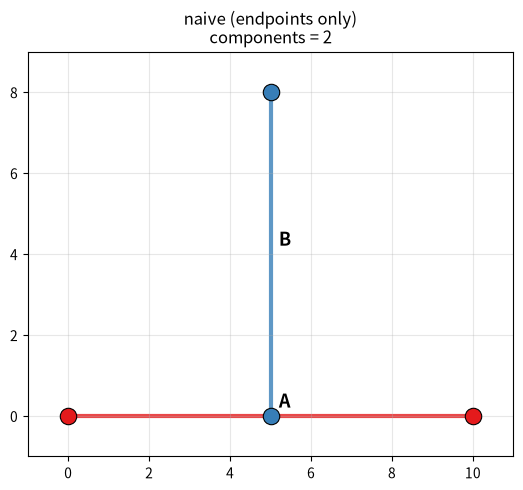

In [3]:
Gn = nx.Graph()
for name, line in roads.items():
    cs = list(line.coords)
    Gn.add_edge(_round_coord(*cs[0]), _round_coord(*cs[-1]), road=name)

print("naive 連通元件數:", nx.number_connected_components(Gn))

fig, ax = plt.subplots(figsize=(6, 5))
draw_graph_2d(Gn, roads, "naive (endpoints only)", ax)
plt.tight_layout(); plt.show()

## 修復：找共享座標 → 在中間點切割

1. 建 `座標 → 屬於哪些道路` 的索引（1m 捨入）
2. `intersection_set` = 出現在 2 條以上道路的座標
3. 每條路在落於 intersection 的中間點切割成多段
4. 重建圖 → 交叉點成為共享節點（同一色、單一分量；`(5,0)` degree=3 被強調）

路口座標（2 條以上共享）: {(5, 0)}
repaired 連通元件數: 1


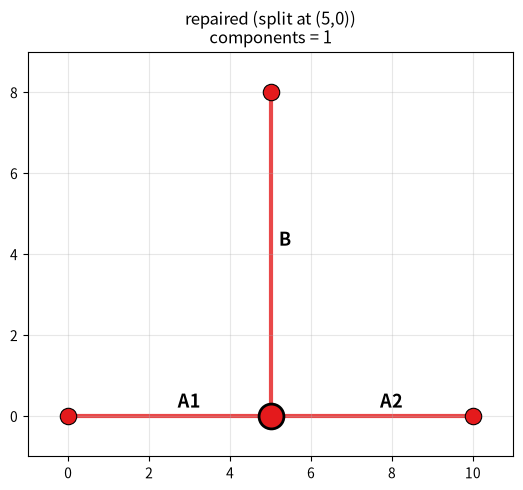

In [4]:
# 步驟 1–2
coord_to_roads = defaultdict(set)
for name, line in roads.items():
    for c in line.coords:
        coord_to_roads[_round_coord(*c)].add(name)
intersection_set = {c for c, rs in coord_to_roads.items() if len(rs) >= 2}
print("路口座標（2 條以上共享）:", intersection_set)

# 步驟 3–4：在路口中間點切割，切出的每小段自成一條 road 供繪圖
Gr = nx.Graph()
roads_split = {}
for name, line in roads.items():
    cs = list(line.coords)
    rc = [_round_coord(*c) for c in cs]
    split = [0] + [i for i in range(1, len(cs) - 1) if rc[i] in intersection_set] + [len(cs) - 1]
    for k, (a, b) in enumerate(zip(split, split[1:])):
        Gr.add_edge(rc[a], rc[b], road=name)
        seg_name = name if len(split) == 2 else f"{name}{k+1}"
        roads_split[seg_name] = LineString(cs[a:b + 1])

print("repaired 連通元件數:", nx.number_connected_components(Gr))

fig, ax = plt.subplots(figsize=(6, 5))
draw_graph_2d(Gr, roads_split, "repaired (split at (5,0))", ax)
plt.tight_layout(); plt.show()

## 3D 分層：為什麼「投影相交 ≠ 連通」

把 naive 的兩條路放在不同 z 層（A→z=0、B→z=1）：投影到 2D 會交會，
但它們在拓撲上位於不同「高度」、沒有共用節點。修復後壓回同一 z=0、`(5,0)` 成為共享節點。

（純直覺輔助；機制本身看上面的連通分量著色圖最精準。）

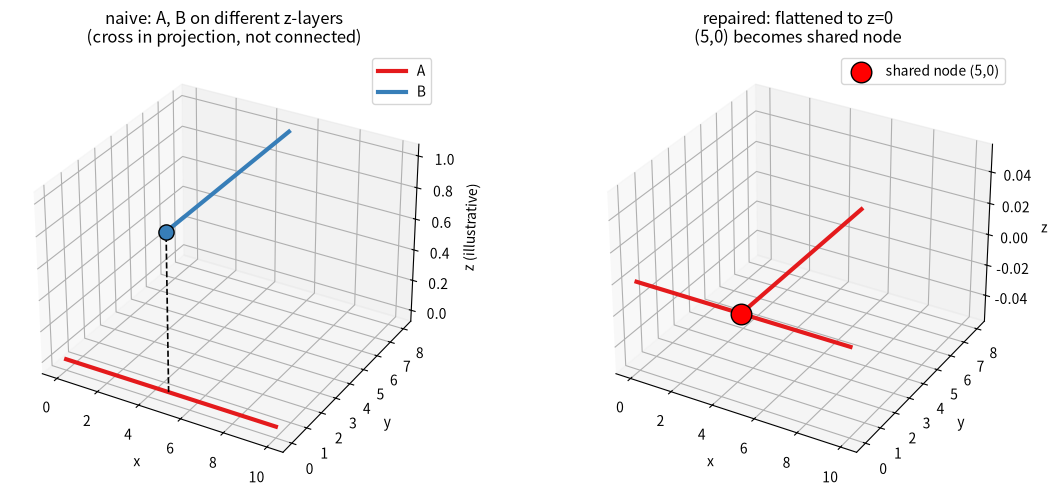

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  註冊 3d projection

fig = plt.figure(figsize=(12, 5))

# 左：naive，A/B 分層
ax1 = fig.add_subplot(121, projection="3d")
zmap = {"A": 0, "B": 1}
for name, line in roads.items():
    xs, ys = line.xy
    ci = 0 if name == "A" else 1
    ax1.plot(xs, ys, [zmap[name]] * len(xs), lw=3, color=COMP_COLORS[ci], label=name)
ax1.plot([5, 5], [0, 0], [0, 1], "k--", lw=1.2)      # 標出投影交會處的「高度差」
ax1.scatter([5], [0], [1], s=120, color=COMP_COLORS[1], edgecolors="black")
ax1.set_title("naive: A, B on different z-layers\n(cross in projection, not connected)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z (illustrative)"); ax1.legend()

# 右：repaired，壓回 z=0
ax2 = fig.add_subplot(122, projection="3d")
for name, line in roads.items():
    xs, ys = line.xy
    ax2.plot(xs, ys, [0] * len(xs), lw=3, color=COMP_COLORS[0])
ax2.scatter([5], [0], [0], s=220, color="red", edgecolors="black", label="shared node (5,0)")
ax2.set_title("repaired: flattened to z=0\n(5,0) becomes shared node")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z"); ax2.legend()

plt.tight_layout(); plt.show()

## 對照 ARCHITECTURE §3.1 的 4 步

toy 的 `2 → 1 連通元件`，就是真實資料 `11% → 97% 連通率` 的縮小版。
下面 **Part B** 就在真實道路上驗證同一件事。

# Topology Repair Demo — Part B（L2 真實 bbox）

在**真實道路**上重現同一概念：切一小塊台北市中心 bbox，
比較 naive 建圖 vs 專案真正的 `build_graph`（拓撲修復）的連通性。

**需要**：`backend/data/raw/gis_osm_roads_free_1.gpkg`（未內建，需先跑
`scripts/download_roads_geofabrik.py` 下載）。若檔案不存在，下一格會提示。

In [6]:
# 以 app 套件位置反推 backend 目錄，避免依賴當前工作目錄
from pathlib import Path
import app, geopandas as gpd
from pyproj import Transformer
from app.config import settings

BACKEND = Path(app.__file__).resolve().parent.parent
ROADS_GPKG = BACKEND / settings.ROADS_GPKG_PATH
print("roads gpkg:", ROADS_GPKG, "exists:", ROADS_GPKG.exists())

# 半徑 600m 台北車站 bbox（EPSG:3857；gpkg 空間索引 → 只讀這塊、很快）
_t = Transformer.from_crs(4326, 3857, always_xy=True)
cx, cy = _t.transform(121.517, 25.048)
HALF = 600
BBOX = (cx - HALF, cy - HALF, cx + HALF, cy + HALF)

assert ROADS_GPKG.exists(), "找不到 roads gpkg，請先跑 scripts/download_roads_geofabrik.py"
roads_raw = gpd.read_file(ROADS_GPKG, bbox=BBOX)

# 前處理對齊 load_and_filter_roads：排除不適合自行車的類型 + 炸成單純 LineString
roads_bbox = roads_raw[~roads_raw["fclass"].isin(settings.EXCLUDED_FCLASSES)].copy()
roads_bbox = roads_bbox.explode(index_parts=False).reset_index(drop=True)
roads_bbox = roads_bbox[roads_bbox.geometry.geom_type == "LineString"].reset_index(drop=True)
print(f"bbox 內道路：{len(roads_raw)} → 篩選後 {len(roads_bbox)} 條")

roads gpkg: /home/su2270853/projects/bike_risk_route_app/backend/data/raw/gis_osm_roads_free_1.gpkg exists: True


bbox 內道路：1041 → 篩選後 895 條


## naive vs build_graph，量化連通性

- **naive**：每條路只連頭尾端點（中間點不成節點）
- **build_graph**：專案真正的修復（在共享座標切割）
- **最大連通比** = 最大連通分量的節點數 / 全部節點數（對應 ARCHITECTURE 的「連通率」）

In [7]:
import networkx as nx
from app.services.graph_builder import build_graph, _round_coord

def connectivity(G):
    n = G.number_of_nodes()
    if n == 0:
        return 0, 0, 0.0
    ncc = nx.number_connected_components(G)
    largest = len(max(nx.connected_components(G), key=len))
    return ncc, n, largest / n

# naive：端點建圖（保留 geometry 供繪圖）
Gn = nx.MultiGraph()
for _, row in roads_bbox.iterrows():
    cs = list(row.geometry.coords)
    a, b = _round_coord(*cs[0]), _round_coord(*cs[-1])
    Gn.add_node(a, x=cs[0][0], y=cs[0][1])
    Gn.add_node(b, x=cs[-1][0], y=cs[-1][1])
    Gn.add_edge(a, b, geometry=row.geometry)

# repaired：專案真正的建圖
Gr = build_graph(roads_bbox)

for label, G in [("naive", Gn), ("build_graph", Gr)]:
    ncc, n, ratio = connectivity(G)
    print(f"{label:12s} 節點={n:5d}  邊={G.number_of_edges():5d}  分量數={ncc:4d}  最大連通比={ratio:6.1%}")

naive        節點= 1224  邊=  895  分量數= 403  最大連通比= 15.4%
build_graph  節點= 1550  邊= 2183  分量數=  29  最大連通比= 92.9%


## 視覺化：主連通網（綠）vs 碎片（灰）

naive 會看到大量灰色孤立碎片、最大連通比低；
build_graph 後幾乎整片變綠、連成單一路網。

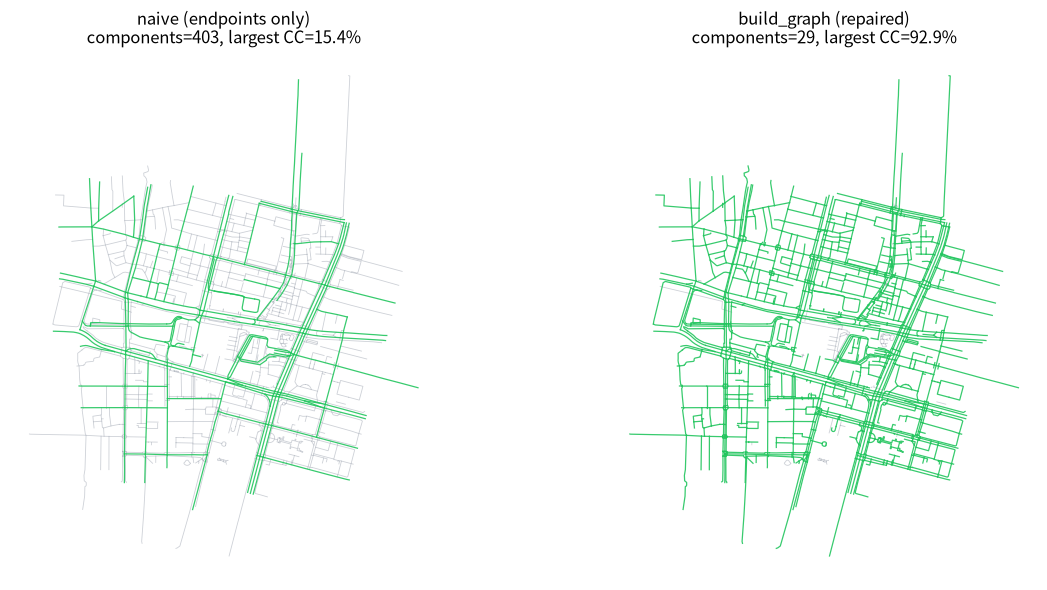

In [8]:
def draw_real(G, title, ax):
    ncc, n, ratio = connectivity(G)
    main = max(nx.connected_components(G), key=len)
    for u, v, data in G.edges(data=True):
        geom = data.get("geometry")
        if geom is None:
            xs = [G.nodes[u]["x"], G.nodes[v]["x"]]; ys = [G.nodes[u]["y"], G.nodes[v]["y"]]
        else:
            xs, ys = geom.xy
        in_main = (u in main) and (v in main)
        ax.plot(xs, ys, color="#22c55e" if in_main else "#9ca3af",
                lw=0.9 if in_main else 0.6, alpha=0.9 if in_main else 0.5,
                zorder=2 if in_main else 1)
    ax.set_title(f"{title}\ncomponents={ncc}, largest CC={ratio:.1%}", fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw_real(Gn, "naive (endpoints only)", axes[0])
draw_real(Gr, "build_graph (repaired)", axes[1])
plt.tight_layout(); plt.show()

## 結論

同一塊真實道路，naive 因為「交叉點落在道路中間、沒被升級成節點」而嚴重斷裂；
`build_graph` 在共享座標切割後，最大連通比大幅提升 —— 與 `ARCHITECTURE.md` 記錄的
`11% → 97% 連通率` 是同一機制在全台尺度的結果。

Part A（toy）解釋「為什麼」，Part B（真實 bbox）證明「在真資料上成立」。